In [27]:
import pydicom
from pydicom.dataset import Dataset, FileDataset
from pydicom.uid import generate_uid
import os
import matplotlib.pylab as plt
import numpy as np
#import cv2
from skimage import exposure

3
['../../../../RadiomiK/Immagini/RADIOMIK_GE/RAD_GE/SHAPE_43/RAD_GE_LUNG_7_FBP_1.dcm', '../../../../RadiomiK/Immagini/RADIOMIK_GE/RAD_GE/SHAPE_43/RAD_GE_LUNG_7_FBP_3.dcm', '../../../../RadiomiK/Immagini/RADIOMIK_GE/RAD_GE/SHAPE_43/RAD_GE_LUNG_7_FBP_2.dcm']
../../../../RadiomiK/Immagini/RADIOMIK_GE/RAD_GE/SHAPE_43/RAD_GE_LUNG_7_FBP_1.dcm
(43, 512, 512)
36863
30768
[0.703125, 0.703125]
43
1.25


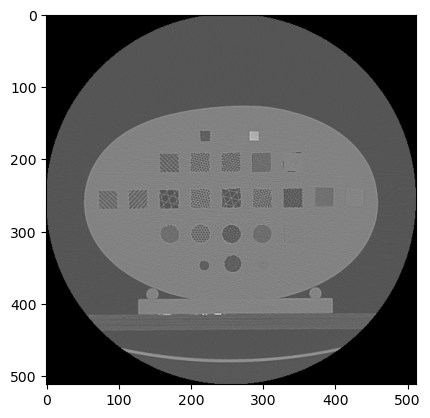

In [ ]:
# Step 1: Load the DICOM image

file_names=[]
directory = '../../../RadiomiK/Immagini/RADIOMIK_GE/RAD_GE/SHAPE_43/'
for filename in os.listdir(directory):
    f = os.path.join(directory, filename)
    if os.path.isfile(f) and filename.endswith('.dcm'):
        file_names.append(f)

print(len(file_names))
#print(file_names[10])
print(file_names)

dicom_image = pydicom.dcmread(file_names[0])  
print(file_names[0])
# Step 2: Extract relevant image information

pixel_array = dicom_image.pixel_array
print(pixel_array.shape)

slice_select = 21 #cambire slice a seconda della shape dell'immagine: 10

pixelarray_slice=pixel_array[slice_select,:,:]   #FINCHE' LA SLICE THICKNESS è LA STESSA, DOVREBBE RIMANERE UGUALE (-1 rispetto a quella di imagej)
#Print max and min values of the pixel array
print(np.max(pixel_array))
print(np.min(pixel_array))

spacing = dicom_image.PixelSpacing
print(spacing)
z_dim = dicom_image.NumberOfFrames
print(z_dim)
# retrive the slice thickness, assuming all slices are the same
slice_thickness = dicom_image.SliceThickness
print(slice_thickness)

plt.imshow(pixelarray_slice, cmap='gray')
plt.show()



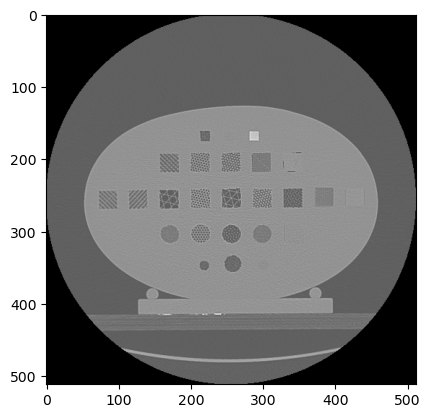

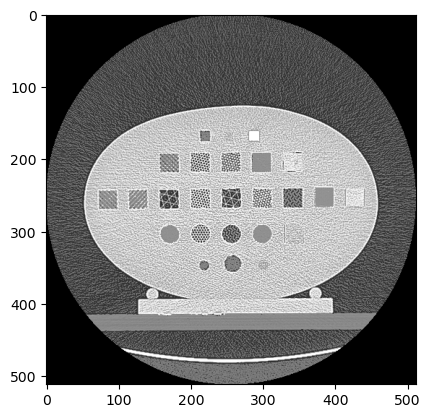

In [29]:
#Equalize the  2D image histogram
# Setting the medium value to the mean of the image and the windows width to 3 times the standard deviation

display_min = np.mean(pixelarray_slice) - 3*np.std(pixelarray_slice)
display_max = np.mean(pixelarray_slice) + 3*np.std(pixelarray_slice)

# Clip the image values to the display range
dicom_image_clipped = np.clip(pixelarray_slice, display_min, display_max)

plt.imshow(dicom_image_clipped, cmap='gray')
plt.show()

# Normalize the clipped image to the [0, 1] range
dicom_image_normalized = (dicom_image_clipped - display_min) / (display_max - display_min)
dicom_image_equalized = exposure.equalize_hist(dicom_image_normalized)

# Display the normalized image using 'gray' colormap
plt.imshow(dicom_image_equalized, cmap='gray')
plt.show()

In [30]:
#ROI definitions
#posizioni del TOSHIBA
#Cylindrical ROI

center_y = [171, 214, 256, 299]  
center_x = [304, 304, 304, 304]
center_x=np.array(center_x)
center_y=np.array(center_y)



'''
#Cylindrical ROI GE dose 4
center_y = [225, 256, 286, 317]
center_x = [291, 291, 290, 290]
'''

center_z = slice_select  
radius = 9  #da verificare
height = 4   #da verificare

#Rectangular ROI
center_x_rect_GE = [171, 213, 256, 298, 341, 86, 128, 170, 213, 256, 299, 342, 385, 427, 343] 
center_y_rect_GE = [206, 206, 206, 206, 206, 257, 256, 256, 256, 256, 255, 255, 254, 254, 304] 
center_x_rect_GE=np.array(center_x_rect_GE)
center_y_rect_GE=np.array(center_y_rect_GE)


'''
#Rectangular ROI GE dose 4
center_x_rect_GE = [225, 256, 286, 317, 347, 86, 117, 147, 178, 208, 239, 269, 300, 330, 361]
center_y_rect_GE = [220, 220, 220, 220, 291, 257, 256, 256, 256, 256, 255, 254, 254, 254, 291]
''' 

width = 9

#Test 75% of the original ROI
radius_75 = 7
height_75 = 3
width_75 = 7

#Test 50% of the original ROI
radius_50 = 5
height_50 = 2
width_50 = 5

# Create a binary mask for cylindrical ROI
maschere=[]

for k, j in zip(center_x, center_y):
    print(k)
    print(j)
    mask3D = np.zeros_like(dicom_image.pixel_array).astype('uint16')

    for i in range (mask3D.shape[0]):
        if i >= center_z - height and i <= center_z + height:
            x, y = np.ogrid[:pixelarray_slice.shape[0], :pixelarray_slice.shape[1]]
            mask3D[i,:,:][np.sqrt((x - k)**2 + (y - j)**2) <= radius] = 1
    print(mask3D.shape)
    maschere.append(mask3D)
        
mask3D_cyl0 = maschere[0]
mask3D_cyl1 = maschere[1]
mask3D_cyl2 = maschere[2]
mask3D_cyl3 = maschere[3]

# Create a binary mask for rectangular ROI
maschere_rect=[]

for k, j in zip(center_x_rect_GE, center_y_rect_GE):
    print(k)
    print(j)
    mask3D_rect = np.zeros_like(dicom_image.pixel_array).astype('uint16')

    for i in range (mask3D_rect.shape[0]):
        if i >= center_z - height and i <= center_z + height:
            mask3D_rect[i,:,:][j-width:j+width, k-width:k+width] = 1
    print(mask3D_rect.shape)
    maschere_rect.append(mask3D_rect)

mask3D_rect0 = maschere_rect[0]
mask3D_rect1 = maschere_rect[1]
mask3D_rect2 = maschere_rect[2]
mask3D_rect3 = maschere_rect[3]
mask3D_rect4 = maschere_rect[4]
mask3D_rect5 = maschere_rect[5]
mask3D_rect6 = maschere_rect[6]
mask3D_rect7 = maschere_rect[7]
mask3D_rect8 = maschere_rect[8]
mask3D_rect9 = maschere_rect[9]
mask3D_rect10 = maschere_rect[10]
mask3D_rect11 = maschere_rect[11]
mask3D_rect12 = maschere_rect[12]
mask3D_rect13 = maschere_rect[13]
mask3D_rect14 = maschere_rect[14]



304
171
(43, 512, 512)
304
214
(43, 512, 512)
304
256
(43, 512, 512)
304
299
(43, 512, 512)
171
206
(43, 512, 512)
213
206
(43, 512, 512)
256
206
(43, 512, 512)
298
206
(43, 512, 512)
341
206
(43, 512, 512)
86
257
(43, 512, 512)
128
256
(43, 512, 512)
170
256
(43, 512, 512)
213
256
(43, 512, 512)
256
256
(43, 512, 512)
299
255
(43, 512, 512)
342
255
(43, 512, 512)
385
254
(43, 512, 512)
427
254
(43, 512, 512)
343
304
(43, 512, 512)


In [31]:
# Create a binary mask for cylindrical ROI 75%
maschere=[]

for k, j in zip(center_x, center_y):
    print(k)
    print(j)
    mask3D = np.zeros_like(dicom_image.pixel_array).astype('uint16')

    for i in range (mask3D.shape[0]):
        if i >= center_z - height_75 and i <= center_z + height_75:
            x, y = np.ogrid[:pixelarray_slice.shape[0], :pixelarray_slice.shape[1]]
            mask3D[i,:,:][np.sqrt((x - k)**2 + (y - j)**2) <= radius_75] = 1
    print(mask3D.shape)
    maschere.append(mask3D)
        
mask3D_cyl0_75 = maschere[0]
mask3D_cyl1_75 = maschere[1]
mask3D_cyl2_75 = maschere[2]
mask3D_cyl3_75 = maschere[3]

# Create a binary mask for rectangular ROI
maschere_rect=[]

for k, j in zip(center_x_rect_GE, center_y_rect_GE):
    print(k)
    print(j)
    mask3D_rect = np.zeros_like(dicom_image.pixel_array).astype('uint16')

    for i in range (mask3D_rect.shape[0]):
        if i >= center_z - height_75 and i <= center_z + height_75:
            mask3D_rect[i,:,:][j-width_75:j+width_75, k-width_75:k+width_75] = 1
    print(mask3D_rect.shape)
    maschere_rect.append(mask3D_rect)

mask3D_rect0_75 = maschere_rect[0]
mask3D_rect1_75 = maschere_rect[1]
mask3D_rect2_75 = maschere_rect[2]
mask3D_rect3_75 = maschere_rect[3]
mask3D_rect4_75 = maschere_rect[4]
mask3D_rect5_75 = maschere_rect[5]
mask3D_rect6_75 = maschere_rect[6]
mask3D_rect7_75 = maschere_rect[7]
mask3D_rect8_75 = maschere_rect[8]
mask3D_rect9_75 = maschere_rect[9]
mask3D_rect10_75 = maschere_rect[10]
mask3D_rect11_75 = maschere_rect[11]
mask3D_rect12_75 = maschere_rect[12]
mask3D_rect13_75 = maschere_rect[13]
mask3D_rect14_75 = maschere_rect[14]

304
171
(43, 512, 512)
304
214
(43, 512, 512)
304
256
(43, 512, 512)
304
299
(43, 512, 512)
171
206
(43, 512, 512)
213
206
(43, 512, 512)
256
206
(43, 512, 512)
298
206
(43, 512, 512)
341
206
(43, 512, 512)
86
257
(43, 512, 512)
128
256
(43, 512, 512)
170
256
(43, 512, 512)
213
256
(43, 512, 512)
256
256
(43, 512, 512)
299
255
(43, 512, 512)
342
255
(43, 512, 512)
385
254
(43, 512, 512)
427
254
(43, 512, 512)
343
304
(43, 512, 512)


In [32]:
# Create a binary mask for cylindrical ROI 50%
maschere=[]

for k, j in zip(center_x, center_y):
    print(k)
    print(j)
    mask3D = np.zeros_like(dicom_image.pixel_array).astype('uint16')

    for i in range (mask3D.shape[0]):
        if i >= center_z - height_50 and i <= center_z + height_50:
            x, y = np.ogrid[:pixelarray_slice.shape[0], :pixelarray_slice.shape[1]]
            mask3D[i,:,:][np.sqrt((x - k)**2 + (y - j)**2) <= radius_50] = 1
    print(mask3D.shape)
    maschere.append(mask3D)
        
mask3D_cyl0_50 = maschere[0]
mask3D_cyl1_50 = maschere[1]
mask3D_cyl2_50 = maschere[2]
mask3D_cyl3_50 = maschere[3]

# Create a binary mask for rectangular ROI
maschere_rect=[]

for k, j in zip(center_x_rect_GE, center_y_rect_GE):
    print(k)
    print(j)
    mask3D_rect = np.zeros_like(dicom_image.pixel_array).astype('uint16')

    for i in range (mask3D_rect.shape[0]):
        if i >= center_z - height_50 and i <= center_z + height_50:
            mask3D_rect[i,:,:][j-width_50:j+width_50, k-width_50:k+width_50] = 1
    print(mask3D_rect.shape)
    maschere_rect.append(mask3D_rect)

mask3D_rect0_50 = maschere_rect[0]
mask3D_rect1_50 = maschere_rect[1]
mask3D_rect2_50 = maschere_rect[2]
mask3D_rect3_50 = maschere_rect[3]
mask3D_rect4_50 = maschere_rect[4]
mask3D_rect5_50 = maschere_rect[5]
mask3D_rect6_50 = maschere_rect[6]
mask3D_rect7_50 = maschere_rect[7]
mask3D_rect8_50 = maschere_rect[8]
mask3D_rect9_50 = maschere_rect[9]
mask3D_rect10_50 = maschere_rect[10]
mask3D_rect11_50 = maschere_rect[11]
mask3D_rect12_50 = maschere_rect[12]
mask3D_rect13_50 = maschere_rect[13]
mask3D_rect14_50 = maschere_rect[14]

304
171
(43, 512, 512)
304
214
(43, 512, 512)
304
256
(43, 512, 512)
304
299
(43, 512, 512)
171
206
(43, 512, 512)
213
206
(43, 512, 512)
256
206
(43, 512, 512)
298
206
(43, 512, 512)
341
206
(43, 512, 512)
86
257
(43, 512, 512)
128
256
(43, 512, 512)
170
256
(43, 512, 512)
213
256
(43, 512, 512)
256
256
(43, 512, 512)
299
255
(43, 512, 512)
342
255
(43, 512, 512)
385
254
(43, 512, 512)
427
254
(43, 512, 512)
343
304
(43, 512, 512)


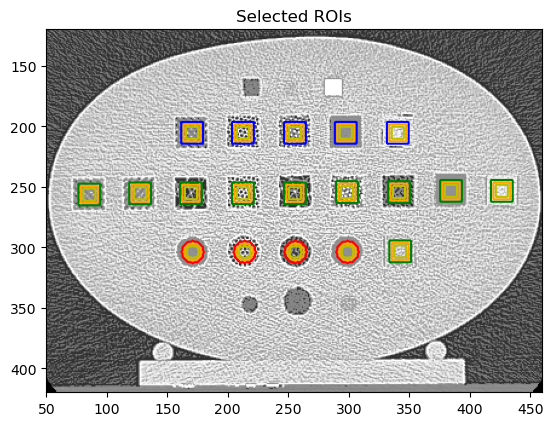

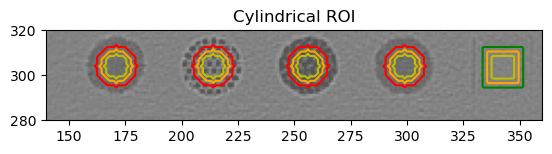

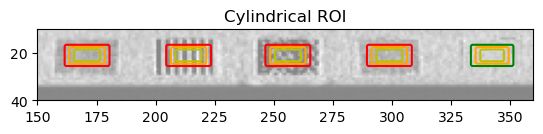

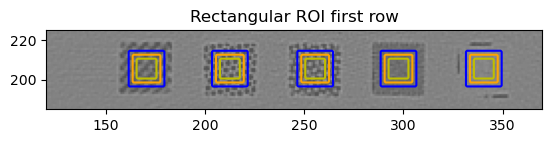

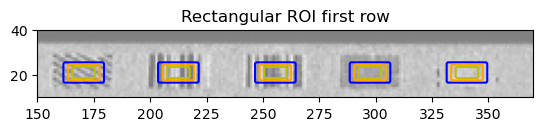

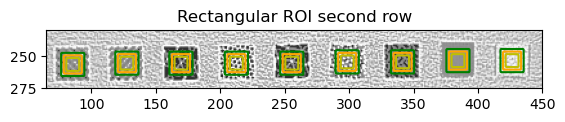

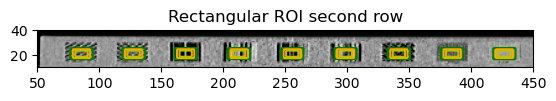

In [33]:
#plot the contours of the ROIs on the image
plt.imshow(dicom_image_equalized, cmap='gray')
plt.contour(mask3D_cyl0[slice_select,:,:], [0.5], colors='r')
plt.contour(mask3D_cyl1[slice_select,:,:], [0.5], colors='r')
plt.contour(mask3D_cyl2[slice_select,:,:], [0.5], colors='r')
plt.contour(mask3D_cyl3[slice_select,:,:], [0.5], colors='r')
plt.contour(mask3D_rect0[slice_select,:,:], [0.5], colors='b')
plt.contour(mask3D_rect1[slice_select,:,:], [0.5], colors='b')
plt.contour(mask3D_rect2[slice_select,:,:], [0.5], colors='b')
plt.contour(mask3D_rect3[slice_select,:,:], [0.5], colors='b')
plt.contour(mask3D_rect4[slice_select,:,:], [0.5], colors='b')
plt.contour(mask3D_rect5[slice_select,:,:], [0.5], colors='g')
plt.contour(mask3D_rect6[slice_select,:,:], [0.5], colors='g')
plt.contour(mask3D_rect7[slice_select,:,:], [0.5], colors='g')
plt.contour(mask3D_rect8[slice_select,:,:], [0.5], colors='g')
plt.contour(mask3D_rect9[slice_select,:,:], [0.5], colors='g')
plt.contour(mask3D_rect10[slice_select,:,:], [0.5], colors='g')
plt.contour(mask3D_rect11[slice_select,:,:], [0.5], colors='g')
plt.contour(mask3D_rect12[slice_select,:,:], [0.5], colors='g')
plt.contour(mask3D_rect13[slice_select,:,:], [0.5], colors='g')
plt.contour(mask3D_rect14[slice_select,:,:], [0.5], colors='g')

plt.contour(mask3D_cyl0_75[slice_select,:,:], [0.5], colors='orange')
plt.contour(mask3D_cyl1_75[slice_select,:,:], [0.5], colors='orange')
plt.contour(mask3D_cyl2_75[slice_select,:,:], [0.5], colors='orange')
plt.contour(mask3D_cyl3_75[slice_select,:,:], [0.5], colors='orange')
plt.contour(mask3D_rect0_75[slice_select,:,:], [0.5], colors='orange')
plt.contour(mask3D_rect1_75[slice_select,:,:], [0.5], colors='orange')
plt.contour(mask3D_rect2_75[slice_select,:,:], [0.5], colors='orange')
plt.contour(mask3D_rect3_75[slice_select,:,:], [0.5], colors='orange')
plt.contour(mask3D_rect4_75[slice_select,:,:], [0.5], colors='orange')
plt.contour(mask3D_rect5_75[slice_select,:,:], [0.5], colors='orange')
plt.contour(mask3D_rect6_75[slice_select,:,:], [0.5], colors='orange')
plt.contour(mask3D_rect7_75[slice_select,:,:], [0.5], colors='orange')
plt.contour(mask3D_rect8_75[slice_select,:,:], [0.5], colors='orange')
plt.contour(mask3D_rect9_75[slice_select,:,:], [0.5], colors='orange')
plt.contour(mask3D_rect10_75[slice_select,:,:], [0.5], colors='orange')
plt.contour(mask3D_rect11_75[slice_select,:,:], [0.5], colors='orange')
plt.contour(mask3D_rect12_75[slice_select,:,:], [0.5], colors='orange')
plt.contour(mask3D_rect13_75[slice_select,:,:], [0.5], colors='orange')
plt.contour(mask3D_rect14_75[slice_select,:,:], [0.5], colors='orange')

plt.contour(mask3D_cyl0_50[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_cyl1_50[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_cyl2_50[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_cyl3_50[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect0_50[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect1_50[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect2_50[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect3_50[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect4_50[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect5_50[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect6_50[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect7_50[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect8_50[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect9_50[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect10_50[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect11_50[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect12_50[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect13_50[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect14_50[slice_select,:,:], [0.5], colors='y')

plt.title('Selected ROIs')
plt.xlim(50, 460)
plt.ylim(420, 120)
plt.show()

#plot the zoomed contours of the cylindrical ROI on the image
plt.imshow(pixelarray_slice, cmap='gray')
plt.contour(mask3D_cyl0[slice_select,:,:], [0.5], colors='r')
plt.contour(mask3D_cyl1[slice_select,:,:], [0.5], colors='r')
plt.contour(mask3D_cyl2[slice_select,:,:], [0.5], colors='r')
plt.contour(mask3D_cyl3[slice_select,:,:], [0.5], colors='r')
plt.contour(mask3D_rect14[slice_select,:,:], [0.5], colors='g')

plt.contour(mask3D_cyl0_75[slice_select,:,:], [0.5], colors='orange')
plt.contour(mask3D_cyl1_75[slice_select,:,:], [0.5], colors='orange')
plt.contour(mask3D_cyl2_75[slice_select,:,:], [0.5], colors='orange')
plt.contour(mask3D_cyl3_75[slice_select,:,:], [0.5], colors='orange')
plt.contour(mask3D_rect14_75[slice_select,:,:], [0.5], colors='orange')

plt.imshow(pixelarray_slice, cmap='gray')
plt.contour(mask3D_cyl0_50[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_cyl1_50[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_cyl2_50[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_cyl3_50[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect14_50[slice_select,:,:], [0.5], colors='y')

plt.xlim(140, 360)
plt.ylim(280, 320)
plt.title('Cylindrical ROI')
plt.show()

#plot the contours of the cylindrical ROI on the image on the z axis
plt.imshow(pixel_array[:, 304, :], cmap='gray')
plt.contour(mask3D_cyl0[:,304,:], [0.5], colors='r')
plt.contour(mask3D_cyl1[:,304,:], [0.5], colors='r')
plt.contour(mask3D_cyl2[:,304,:], [0.5], colors='r')
plt.contour(mask3D_cyl3[:,304,:], [0.5], colors='r')
plt.contour(mask3D_rect14[:,304,:], [0.5], colors='g')

plt.contour(mask3D_cyl0_75[:,304,:], [0.5], colors='orange')
plt.contour(mask3D_cyl1_75[:,304,:], [0.5], colors='orange')
plt.contour(mask3D_cyl2_75[:,304,:], [0.5], colors='orange')
plt.contour(mask3D_cyl3_75[:,304,:], [0.5], colors='orange')
plt.contour(mask3D_rect14_75[:,304,:], [0.5], colors='orange')

plt.contour(mask3D_cyl0_50[:,304,:], [0.5], colors='y')
plt.contour(mask3D_cyl1_50[:,304,:], [0.5], colors='y')
plt.contour(mask3D_cyl2_50[:,304,:], [0.5], colors='y')
plt.contour(mask3D_cyl3_50[:,304,:], [0.5], colors='y')
plt.contour(mask3D_rect14_50[:,304,:], [0.5], colors='y')

plt.title('Cylindrical ROI')
plt.xlim(150, 360)
plt.ylim(40, 10)
plt.show()

#plot the zoomed contours of the rectangular ROI on the image
plt.imshow(pixelarray_slice, cmap='gray')
plt.contour(mask3D_rect0[slice_select,:,:], [0.5], colors='b')
plt.contour(mask3D_rect1[slice_select,:,:], [0.5], colors='b')
plt.contour(mask3D_rect2[slice_select,:,:], [0.5], colors='b')
plt.contour(mask3D_rect3[slice_select,:,:], [0.5], colors='b')
plt.contour(mask3D_rect4[slice_select,:,:], [0.5], colors='b')

plt.contour(mask3D_rect0_75[slice_select,:,:], [0.5], colors='orange')
plt.contour(mask3D_rect1_75[slice_select,:,:], [0.5], colors='orange')
plt.contour(mask3D_rect2_75[slice_select,:,:], [0.5], colors='orange')
plt.contour(mask3D_rect3_75[slice_select,:,:], [0.5], colors='orange')
plt.contour(mask3D_rect4_75[slice_select,:,:], [0.5], colors='orange')

plt.imshow(pixelarray_slice, cmap='gray')
plt.contour(mask3D_rect0_50[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect1_50[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect2_50[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect3_50[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect4_50[slice_select,:,:], [0.5], colors='y')

plt.xlim(120, 370)
plt.ylim(185, 225)
plt.title('Rectangular ROI first row')
plt.show()

#plot the contours of the rectangular ROI on the image on the z axis
plt.imshow(pixel_array[:, 206, :], cmap='gray')
plt.contour(mask3D_rect0[:,206,:], [0.5], colors='b')
plt.contour(mask3D_rect1[:,206,:], [0.5], colors='b')
plt.contour(mask3D_rect2[:,206,:], [0.5], colors='b')
plt.contour(mask3D_rect3[:,206,:], [0.5], colors='b')
plt.contour(mask3D_rect4[:,206,:], [0.5], colors='b')

plt.contour(mask3D_rect0_75[:,206,:], [0.5], colors='orange')
plt.contour(mask3D_rect1_75[:,206,:], [0.5], colors='orange')
plt.contour(mask3D_rect2_75[:,206,:], [0.5], colors='orange')
plt.contour(mask3D_rect3_75[:,206,:], [0.5], colors='orange')
plt.contour(mask3D_rect4_75[:,206,:], [0.5], colors='orange')

plt.contour(mask3D_rect0_50[:,206,:], [0.5], colors='y')
plt.contour(mask3D_rect1_50[:,206,:], [0.5], colors='y')
plt.contour(mask3D_rect2_50[:,206,:], [0.5], colors='y')
plt.contour(mask3D_rect3_50[:,206,:], [0.5], colors='y')
plt.contour(mask3D_rect4_50[:,206,:], [0.5], colors='y')

plt.title('Rectangular ROI first row')
plt.xlim(150, 370)
plt.ylim(10, 40)
plt.show()

#plot the zoomed contours of the rectangular ROI on the image
plt.imshow(dicom_image_equalized, cmap='gray')
plt.contour(mask3D_rect5[slice_select,:,:], [0.5], colors='g')
plt.contour(mask3D_rect6[slice_select,:,:], [0.5], colors='g')
plt.contour(mask3D_rect7[slice_select,:,:], [0.5], colors='g')
plt.contour(mask3D_rect8[slice_select,:,:], [0.5], colors='g')
plt.contour(mask3D_rect9[slice_select,:,:], [0.5], colors='g')
plt.contour(mask3D_rect10[slice_select,:,:], [0.5], colors='g')
plt.contour(mask3D_rect11[slice_select,:,:], [0.5], colors='g')
plt.contour(mask3D_rect12[slice_select,:,:], [0.5], colors='g')
plt.contour(mask3D_rect13[slice_select,:,:], [0.5], colors='g')

plt.contour(mask3D_rect5_75[slice_select,:,:], [0.5], colors='orange')
plt.contour(mask3D_rect6_75[slice_select,:,:], [0.5], colors='orange')
plt.contour(mask3D_rect7_75[slice_select,:,:], [0.5], colors='orange')
plt.contour(mask3D_rect8_75[slice_select,:,:], [0.5], colors='orange')
plt.contour(mask3D_rect9_75[slice_select,:,:], [0.5], colors='orange')
plt.contour(mask3D_rect10_75[slice_select,:,:], [0.5], colors='orange')
plt.contour(mask3D_rect11_75[slice_select,:,:], [0.5], colors='orange')
plt.contour(mask3D_rect12_75[slice_select,:,:], [0.5], colors='orange')
plt.contour(mask3D_rect13_75[slice_select,:,:], [0.5], colors='orange')

plt.contour(mask3D_rect5_50[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect6_50[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect7_50[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect8_50[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect9_50[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect10_50[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect11_50[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect12_50[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect13_50[slice_select,:,:], [0.5], colors='y')

plt.xlim(65, 450)
plt.ylim(275, 230)
plt.title('Rectangular ROI second row')
plt.show()

#plot the contours of the rectangular ROI on the image on the z axis
plt.imshow(pixel_array[:, 256, :], cmap='gray')
plt.contour(mask3D_rect5[:,256,:], [0.5], colors='g')
plt.contour(mask3D_rect6[:,256,:], [0.5], colors='g')
plt.contour(mask3D_rect7[:,256,:], [0.5], colors='g')
plt.contour(mask3D_rect8[:,256,:], [0.5], colors='g')
plt.contour(mask3D_rect9[:,256,:], [0.5], colors='g')
plt.contour(mask3D_rect10[:,256,:], [0.5], colors='g')
plt.contour(mask3D_rect11[:,256,:], [0.5], colors='g')
plt.contour(mask3D_rect12[:,256,:], [0.5], colors='g')
plt.contour(mask3D_rect13[:,256,:], [0.5], colors='g')

plt.contour(mask3D_rect5_75[:,256,:], [0.5], colors='orange')
plt.contour(mask3D_rect6_75[:,256,:], [0.5], colors='orange')
plt.contour(mask3D_rect7_75[:,256,:], [0.5], colors='orange')
plt.contour(mask3D_rect8_75[:,256,:], [0.5], colors='orange')
plt.contour(mask3D_rect9_75[:,256,:], [0.5], colors='orange')
plt.contour(mask3D_rect10_75[:,256,:], [0.5], colors='orange')
plt.contour(mask3D_rect11_75[:,256,:], [0.5], colors='orange')
plt.contour(mask3D_rect12_75[:,256,:], [0.5], colors='orange')
plt.contour(mask3D_rect13_75[:,256,:], [0.5], colors='orange')

plt.imshow(pixel_array[:, 256, :], cmap='gray')
plt.contour(mask3D_rect5_50[:,256,:], [0.5], colors='y')
plt.contour(mask3D_rect6_50[:,256,:], [0.5], colors='y')
plt.contour(mask3D_rect7_50[:,256,:], [0.5], colors='y')
plt.contour(mask3D_rect8_50[:,256,:], [0.5], colors='y')
plt.contour(mask3D_rect9_50[:,256,:], [0.5], colors='y')
plt.contour(mask3D_rect10_50[:,256,:], [0.5], colors='y')
plt.contour(mask3D_rect11_50[:,256,:], [0.5], colors='y')
plt.contour(mask3D_rect12_50[:,256,:], [0.5], colors='y')
plt.contour(mask3D_rect13_50[:,256,:], [0.5], colors='y')

plt.title('Rectangular ROI second row')
plt.xlim(50, 450)
plt.ylim(10, 40)
plt.show()



In [34]:
def create_dicom_from_array(mask, output_path, path):
    # Create a new DICOM dataset
    ds = FileDataset(output_path, {}, file_meta=dicom_image.file_meta, preamble=b'\0' * 128)
    ds.SOPClassUID = '1.2.840.10008.5.1.4.1.1.66' # DICOM SEG   #'1.2.840.10008.5.1.4.1.1.2'  # CT Image Storage
    ds.SOPInstanceUID = generate_uid()
    ds.file_meta = pydicom.Dataset()
    ds.FrameOfReferenceUID = dicom_image.FrameOfReferenceUID  
    ds.ImagePositionPatient = dicom_image.ImagePositionPatient
    ds.ImageOrientationPatient = dicom_image.ImageOrientationPatient

    # Set necessary metadata
    ds.PatientName = 'Anonymous'
    ds.PatientID = dicom_image.PatientID
    ds.Rows = mask.shape[1]
    ds.Columns = mask.shape[2]
    ds.PixelSpacing = dicom_image.PixelSpacing  # Define pixel spacing
    ds.SliceThickness = dicom_image.SliceThickness  # Define slice thickness
    ds.NumberOfFrames = mask.shape[0]
    ds.SamplesPerPixel = dicom_image.SamplesPerPixel # Set Samples Per Pixel
    ds.PhotometricInterpretation = 'MONOCHROME2'  # Set Photometric Interpretation
    ds.BitsAllocated = 16
    ds.BitsStored = 16
    ds.HighBit = 15
    ds.PixelRepresentation = 1  # Unsigned integer
    if hasattr(dicom_image, 'RotationDirection'):
        ds.RotationDirection = dicom_image.RotationDirection
    ds.PositionReferenceIndicator = dicom_image.PositionReferenceIndicator
    if hasattr(dicom_image, 'SliceLocation'):
        ds.SliceLocation = dicom_image.SliceLocation
    if hasattr(dicom_image, 'PatientPosition'):
        ds.PatientPosition = dicom_image.PatientPosition

    # Set pixel data
    ds.PixelData = mask.tobytes()
    
    ds.file_meta.TransferSyntaxUID = pydicom.uid.ImplicitVRLittleEndian
    # Save the DICOM file
    ds.save_as(path+output_path)

In [35]:
# Usage
maschere = [mask3D_cyl0, mask3D_cyl1, mask3D_cyl2, mask3D_cyl3, mask3D_rect0, mask3D_rect1, mask3D_rect2, mask3D_rect3, mask3D_rect4, mask3D_rect5, mask3D_rect6, mask3D_rect7, mask3D_rect8, mask3D_rect9, mask3D_rect10, mask3D_rect11, mask3D_rect12, mask3D_rect13, mask3D_rect14] 
output_path = ['mask_cyl0_GE.dcm', 'mask_cyl1_GE.dcm', 'mask_cyl2_GE.dcm', 'mask_cyl3_GE.dcm', 'mask_rect0_GE.dcm', 'mask_rect1_GE.dcm', 'mask_rect2_GE.dcm', 'mask_rect3_GE.dcm', 'mask_rect4_GE.dcm', 'mask_rect5_GE.dcm', 'mask_rect6_GE.dcm', 'mask_rect7_GE.dcm', 'mask_rect8_GE.dcm', 'mask_rect9_GE.dcm', 'mask_rect10_GE.dcm', 'mask_rect11_GE.dcm', 'mask_rect12_GE.dcm', 'mask_rect13_GE.dcm', 'mask_rect14_GE.dcm']
path = '../../../../RadiomiK/Immagini/RADIOMIK_GE/RAD_GE_Volume_test_mask/Test_100/'  # Output path for the DICOM file

for mask_name, output in zip (maschere, output_path):
    
    create_dicom_from_array(mask_name, output, path)

maschere = [mask3D_cyl0_75, mask3D_cyl1_75, mask3D_cyl2_75, mask3D_cyl3_75, mask3D_rect0_75, mask3D_rect1_75, mask3D_rect2_75, mask3D_rect3_75, mask3D_rect4_75, mask3D_rect5_75, mask3D_rect6_75, mask3D_rect7_75, mask3D_rect8_75, mask3D_rect9_75, mask3D_rect10_75, mask3D_rect11_75, mask3D_rect12_75, mask3D_rect13_75, mask3D_rect14_75] 
output_path = ['mask_cyl0_GE.dcm', 'mask_cyl1_GE.dcm', 'mask_cyl2_GE.dcm', 'mask_cyl3_GE.dcm', 'mask_rect0_GE.dcm', 'mask_rect1_GE.dcm', 'mask_rect2_GE.dcm', 'mask_rect3_GE.dcm', 'mask_rect4_GE.dcm', 'mask_rect5_GE.dcm', 'mask_rect6_GE.dcm', 'mask_rect7_GE.dcm', 'mask_rect8_GE.dcm', 'mask_rect9_GE.dcm', 'mask_rect10_GE.dcm', 'mask_rect11_GE.dcm', 'mask_rect12_GE.dcm', 'mask_rect13_GE.dcm', 'mask_rect14_GE.dcm']
path = '../../../../RadiomiK/Immagini/RADIOMIK_GE/RAD_GE_Volume_test_mask/Test_75/'  # Output path for the DICOM file

for mask_name, output in zip (maschere, output_path):
    
    create_dicom_from_array(mask_name, output, path)

maschere = [mask3D_cyl0_50, mask3D_cyl1_50, mask3D_cyl2_50, mask3D_cyl3_50, mask3D_rect0_50, mask3D_rect1_50, mask3D_rect2_50, mask3D_rect3_50, mask3D_rect4_50, mask3D_rect5_50, mask3D_rect6_50, mask3D_rect7_50, mask3D_rect8_50, mask3D_rect9_50, mask3D_rect10_50, mask3D_rect11_50, mask3D_rect12_50, mask3D_rect13_50, mask3D_rect14_50]
output_path = ['mask_cyl0_GE.dcm', 'mask_cyl1_GE.dcm', 'mask_cyl2_GE.dcm', 'mask_cyl3_GE.dcm', 'mask_rect0_GE.dcm', 'mask_rect1_GE.dcm', 'mask_rect2_GE.dcm', 'mask_rect3_GE.dcm', 'mask_rect4_GE.dcm', 'mask_rect5_GE.dcm', 'mask_rect6_GE.dcm', 'mask_rect7_GE.dcm', 'mask_rect8_GE.dcm', 'mask_rect9_GE.dcm', 'mask_rect10_GE.dcm', 'mask_rect11_GE.dcm', 'mask_rect12_GE.dcm', 'mask_rect13_GE.dcm', 'mask_rect14_GE.dcm']
path = '../../../../RadiomiK/Immagini/RADIOMIK_GE/RAD_GE_Volume_test_mask/Test_50/'  # Output path for the DICOM file

for mask_name, output in zip (maschere, output_path):
        
        create_dicom_from_array(mask_name, output, path)

